In [13]:
from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf
from neuromodes.waves import mass_normalize
import numpy as np
import matplotlib.pyplot as plt

In [14]:
solver = EigenSolver(fetch_example_surf(density='4k')[0]).compute_lbo(lump=True)

In [15]:
n_maps = 1000
noise = np.random.default_rng(0).standard_normal((solver.n_verts, n_maps))

In [16]:
# # quick test that variance is similar when mass is lumped or not
# map = noise[:, 100]
# var = map.T @ solver.compute_lbo(lump=False).mass @ map
# var_lumped = map.T @ solver.compute_lbo(lump=True).mass @ map
# print(f"Variance (mass lumped): {var_lumped:.4f}")
# print(f"Variance (mass not lumped): {var:.4f}")
# print(f"Relative difference: {var_lumped / var:.4f}")

In [17]:
noise_norm = mass_normalize(noise, solver.mass)

In [18]:
# histogram of variances (trace of noise_norm.T @ mass @ noise_norm)
massvar_norm = np.einsum('ij,ij->j', noise_norm, solver.mass @ noise_norm)

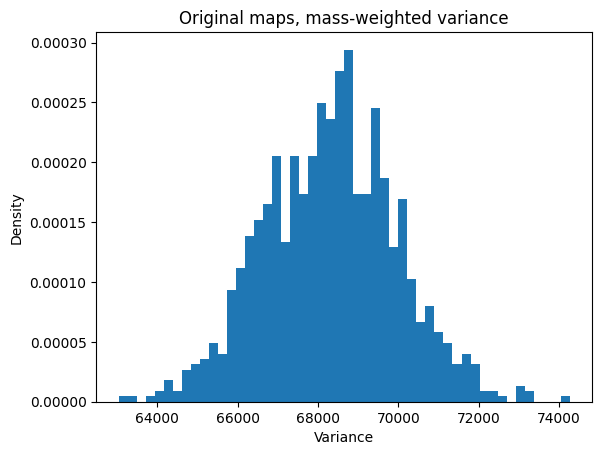

In [19]:
massvar = np.einsum('ij,ij->j', noise, solver.mass @ noise)
assert massvar.shape == (n_maps,)

plt.hist(massvar, bins=50, density=True)
plt.xlabel('Variance')
plt.ylabel('Density')
plt.title('Original maps, mass-weighted variance')
plt.show()

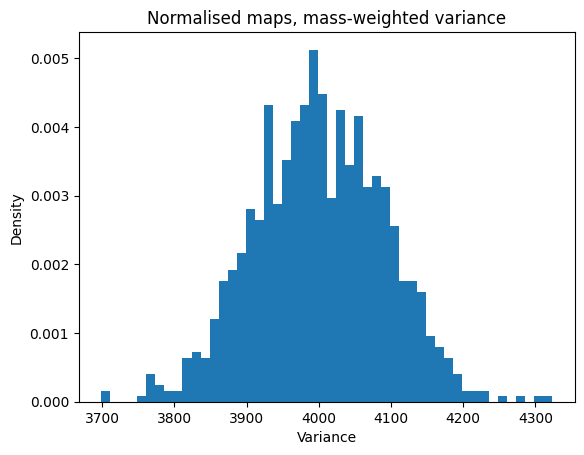

In [20]:
plt.hist(massvar_norm, bins=50, density=True)
plt.xlabel('Variance')
plt.ylabel('Density')
plt.title('Normalised maps, mass-weighted variance')
plt.show()

In [21]:
var = np.var(noise, axis=0)
var_norm = np.var(noise_norm, axis=0)

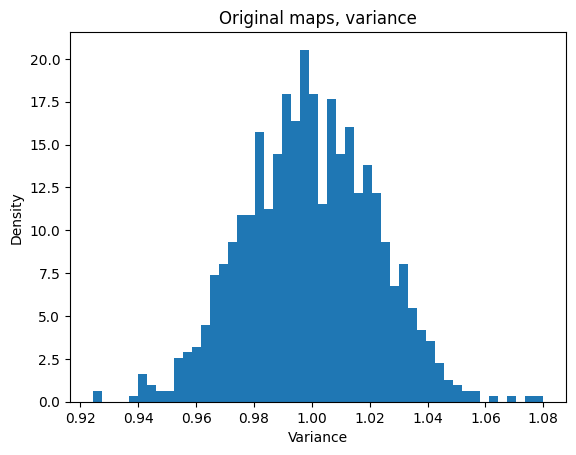

In [22]:
plt.hist(var, bins=50, density=True)
plt.xlabel('Variance')
plt.ylabel('Density')
plt.title('Original maps, variance')
plt.show()

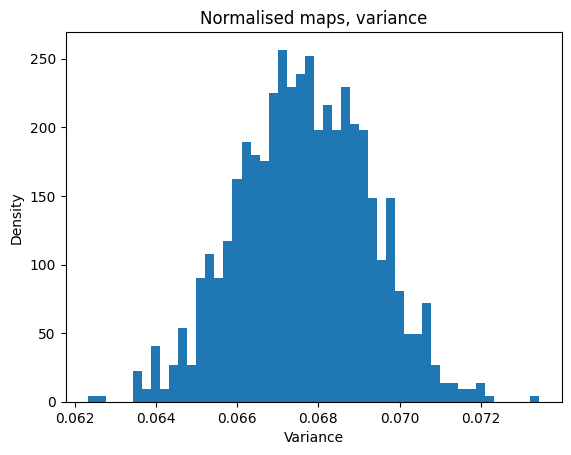

In [23]:
plt.hist(var_norm, bins=50, density=True)
plt.xlabel('Variance')
plt.ylabel('Density')
plt.title('Normalised maps, variance')
plt.show()